### Ici on veut predire la reussite des élèves à partir des donnees "Student Performance in Exam" de kaggle

Pour se faire, on va suivre 7 étapes :
* l'EDA
* le preprocessing
* la separation train/test
* l'entrainement de modele
* l'elavuation
* l'amelioration
* la prediction

### Ici on commence par l'EDA 
On va à la fois importer les bibliothèques qu'on aura besoin pour le projet 

Petit remarque: ici on a un problème de classification (reussir ou non) dont on peut le representer comme un problème de classification binaire
Donc on va choisir l'algorithme *regression logisctic* : modele de classification binaire et *le random forest* : robuste

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib 

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report,roc_auc_score
 

df = pd.read_csv("E:/mySQL/Student_perform.csv", sep = ";")
df

#EDA 
df.info() #information de notre donnees: les colonnes, leurs types, non-null count

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
 8   categorie                    1000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 50.8+ KB


,math score,reading score,writing score,categorie
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000,0.897000
std,15.16308,14.600192,15.195657,0.304111
min,0.00000,17.000000,10.000000,0.000000
25%,57.00000,59.000000,57.750000,1.000000
50%,66.00000,70.000000,69.000000,1.000000
75%,77.00000,79.000000,79.000000,1.000000
max,100.00000,100.000000,100.000000,1.000000


* remarque : d'apres ces statistiques, on a une donnée un peu hétérogene, les moyennes de notes que les élèves ont obtenu sont autour de 66,68,69 tandis qu'au niveau de l'ecart-type, on a un ecart-type un peu élevé pour chaque matière

regardons de pres les ecarts:
pour le math c'est entre 50,92592 et 81,25208
pour le reading, entre 54,569 et 83,769
pour le writing entre 52,858 rt 83,24 
la fourchette nous révèle un ecart d'environ 30 points pour ces notes, cela veut dire qu'il avait eu des élèves qui ont eu que des notes environ de 50 et des eleves qui ont été très excellent, avec des notes environ 81
conclusion: notre donnée est un peu dispersé, et la note min et max dans les matières en témognent aussi 

In [5]:
(df["math score"]<=50).value_counts()

False    850
True     150
Name: math score, dtype: int64

In [6]:
(df["math score"]>=50).value_counts()

True     865
False    135
Name: math score, dtype: int64

In [ ]:
d'apres les resultats ci-dessus, en ayant prix que le math score, beaucoup d'élèves ont eu la moyenne, tandis que peu d'élèves sont au dessous de la moyenne

Alors on peut se poser la question "quelle est la raison de cette dispersion?"

### Ici on veut visualiser l'importance de quelques variables sur nos données 
On va éliminer les varibales qui ne seraient pas vraiment utiles pour notre prediction, pour se faire , on va visualiser le graphique, et la variable avec les proprtions qui sont identiques partout sera effacée

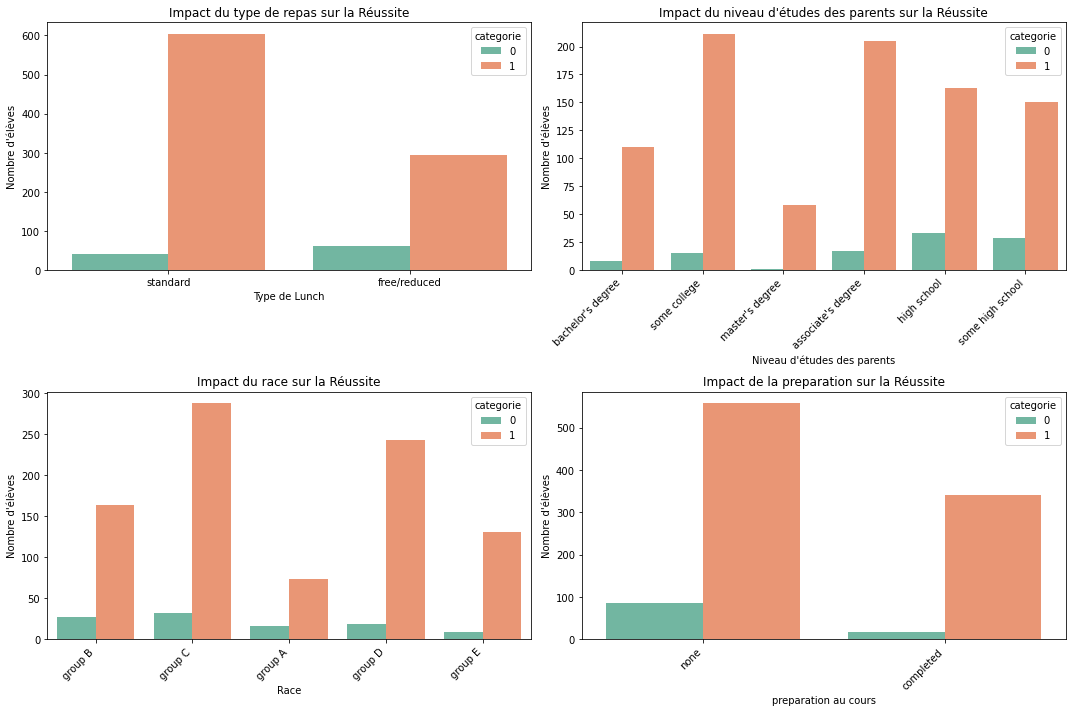

In [7]:
plt.figure(figsize=(15, 10))

#Graphique pour la variable 'lunch'
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='lunch', hue='categorie', palette='Set2')
plt.title("Impact du type de repas sur la Réussite")
plt.xlabel("Type de Lunch")
plt.ylabel("Nombre d'élèves")

# 2. Graphique pour la variable 'parental level of education'
plt.subplot(2, 2, 2)
sns.countplot(data=df, x='parental level of education', hue='categorie', palette='Set2')
plt.title("Impact du niveau d'études des parents sur la Réussite")
plt.xlabel("Niveau d'études des parents")
plt.ylabel("Nombre d'élèves")
plt.xticks(rotation=45, ha='right')

# Graphique pour la variable 'race/ethnicity'
plt.subplot(2, 2, 3)
sns.countplot(data=df, x='race/ethnicity', hue='categorie', palette='Set2')
plt.title("Impact du race sur la Réussite")
plt.xlabel("Race")
plt.ylabel("Nombre d'élèves")
plt.xticks(rotation=45, ha='right') 

#Graphique pour la variable 'test preparation course'
plt.subplot(2, 2, 4)
sns.countplot(data=df, x='test preparation course', hue='categorie', palette='Set2')
plt.title("Impact de la preparation sur la Réussite")
plt.xlabel("preparation au cours")
plt.ylabel("Nombre d'élèves")
plt.xticks(rotation=45, ha='right') 
# Affichage des graphiques
plt.tight_layout()
plt.show()

D'apres ces graphiques, on va supprimer "race/ethnicity" pour notre analyse

### Le preprocessing
Ici on va faire une transformation des donnees, encoder les variables pour qu'elles soient exploitables, supprimer les variables inutiles 

In [8]:
donnees = df.copy()
donnees = donnees.drop(['gender','race/ethnicity','math score','reading score','writing score'], axis = 1)
donnees

,parental level of education,lunch,test preparation course,categorie
0,bachelor's degree,standard,none,1
1,some college,standard,completed,1
2,master's degree,standard,none,1
3,associate's degree,free/reduced,none,0
4,some college,standard,none,1
...,...,...,...,...
995,master's degree,standard,completed,1
996,high school,free/reduced,none,1
997,high school,free/reduced,completed,1
998,some college,standard,completed,1


In [9]:
print(df['test preparation course'].unique())

['none' 'completed']


In [10]:
#On va encoder nos variables à données textuelles pourqu'elles soient utilisables
#pour les deux variables à valeurs sous la forme binaire, on va utiliser 'LabelEncoder': utile pour une variable binaire
#pour parental level of education, on va utiliser "get_dummies"

le = LabelEncoder()

donnees['lunch'] = le.fit_transform(donnees['lunch'])
donnees['test preparation course'] = le.fit_transform(donnees['test preparation course'])
donnees = pd.get_dummies(donnees, 'parental level of education',drop_first=True)

donnees

,lunch,test preparation course,categorie,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school
0,1,1,1,1,0,0,0,0
1,1,0,1,0,0,0,1,0
2,1,1,1,0,0,1,0,0
3,0,1,0,0,0,0,0,0
4,1,1,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...
995,1,0,1,0,0,1,0,0
996,0,1,1,0,1,0,0,0
997,0,0,1,0,1,0,0,0
998,1,0,1,0,0,0,1,0


In [11]:
donnees.isna().sum() #securité

lunch                                            0
test preparation course                          0
categorie                                        0
parental level of education_bachelor's degree    0
parental level of education_high school          0
parental level of education_master's degree      0
parental level of education_some college         0
parental level of education_some high school     0
dtype: int64

### maintenant le split de donnees

In [12]:
#separation des donnees en train et test
X =donnees.drop(['categorie'], axis = 1)
y = donnees['categorie']

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state = 42, stratify = y)

print("Dimensions de X_train :", X_train.shape)
print("Dimensions de X_test  :", X_test.shape)
print("Dimensions de y_train :", y_train.shape)
print("Dimensions de y_test  :", y_test.shape)

Dimensions de X_train : (800, 7)
Dimensions de X_test  : (200, 7)
Dimensions de y_train : (800,)
Dimensions de y_test  : (200,)


### on va maintenant entrainer le modele

In [13]:
#on va utiliser l'algorithme de "regression logistic" et "random forest" car on a un problème de classification,
#et notre target est à valeur binaire

model_logistic = LogisticRegression(max_iter = 1000, random_state = 42)
model_randomF = RandomForestClassifier(random_state = 42)

#entrainement
model_logistic.fit(X_train,y_train)
model_randomF.fit(X_train,y_train)

#test
pred_logistic = model_logistic.predict(X_test)
pred_randomF = model_randomF.predict(X_test)

#evaluation
print(accuracy_score(y_test,pred_logistic))
print(accuracy_score(y_test,pred_randomF))
print("----------------------------------")
print(classification_report(y_test, pred_logistic))
print(classification_report(y_test, pred_randomF))

0.895
0.895
----------------------------------
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        21
           1       0.90      1.00      0.94       179

    accuracy                           0.90       200
   macro avg       0.45      0.50      0.47       200
weighted avg       0.80      0.90      0.85       200

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        21
           1       0.90      1.00      0.94       179

    accuracy                           0.90       200
   macro avg       0.45      0.50      0.47       200
weighted avg       0.80      0.90      0.85       200



C:\ProgramData\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1221: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


d'après cette evaluation, on a un problème,car le modele predit 0 pour precision,recall et f1-score, la raison c'est que nos donnees sont déséquilibrées beaucoup de 1 pour la categorie, donc on gère cela avec "class_weight='balanced' "

In [14]:
model_logistic = LogisticRegression(max_iter = 1000,class_weight='balanced', random_state = 42)
model_randomF = RandomForestClassifier(class_weight='balanced',random_state = 42)

#entrainement
model_logistic.fit(X_train,y_train)
model_randomF.fit(X_train,y_train)

#test
pred_logistic = model_logistic.predict(X_test)
pred_randomF = model_randomF.predict(X_test)

#evaluation

#accuracy
print("regression logistique :",accuracy_score(y_test,pred_logistic))
print("random forest",accuracy_score(y_test,pred_randomF))
print("----------------------------------")

#classification report
print("regression logistique :\n",classification_report(y_test, pred_logistic))
print("random forest:\n ",classification_report(y_test, pred_randomF))

print("----------------------------------")

#  ROC-AUC
prob_logistic = model_logistic.predict_proba(X_test)[:, 1]
prob_randomF = model_randomF.predict_proba(X_test)[:, 1]

auc_logistic = roc_auc_score(y_test, prob_logistic)
auc_rf = roc_auc_score(y_test, prob_randomF)

print("regression logistique :",auc_logistic)
print("random forest :",auc_rf)

regression logistique : 0.7
random forest 0.75
----------------------------------
regression logistique :
               precision    recall  f1-score   support

           0       0.23      0.81      0.36        21
           1       0.97      0.69      0.80       179

    accuracy                           0.70       200
   macro avg       0.60      0.75      0.58       200
weighted avg       0.89      0.70      0.76       200

random forest:
                precision    recall  f1-score   support

           0       0.20      0.48      0.29        21
           1       0.93      0.78      0.85       179

    accuracy                           0.75       200
   macro avg       0.57      0.63      0.57       200
weighted avg       0.85      0.75      0.79       200

----------------------------------
regression logistique : 0.8006118648576749
random forest : 0.7202713487629689


Text(0, 0.5, 'Variables explicatives')

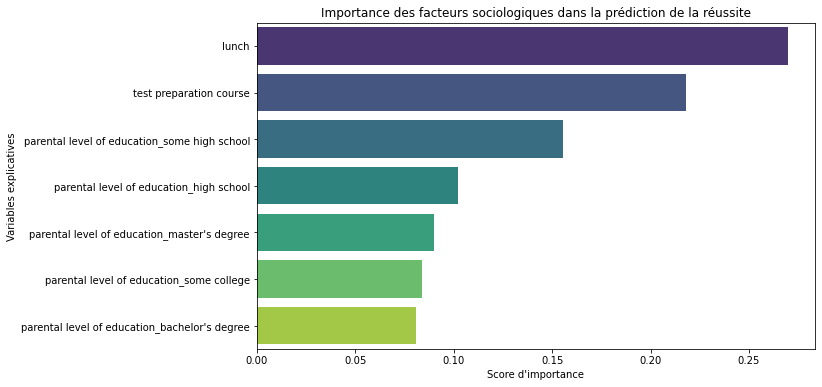

In [15]:

# 1. Extraction de l'importance des variables
importances = model_randomF.feature_importances_
indices = X.columns

# 2. Création d'un DataFrame pour faciliter l'affichage
df_importance = pd.DataFrame({'Variable': indices, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=False) #triage de façon ascendante

# 3. Affichage du graphique
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Variable', data=df_importance, palette='viridis')
plt.title("Importance des facteurs sociologiques dans la prédiction de la réussite")
plt.xlabel("Score d'importance")
plt.ylabel("Variables explicatives")

### Prediction 

On va charger le meilleur modele pour la prediction dans le fichier 'modele_logistisque.pkl' grâce au package joblib pourqu'on a plus à refaire les differents etapes ci-dessus

pour la suite, il faut que les donnees soient coherents aux données entrainées, dans la partie "preprocessing" on a encodé les variables, mais dans ces codes ci-dessous, on a donné privilège aux utilisateurs d'entrer les valeurs de types string mais on a numériser ces valeurs

In [31]:
joblib.dump(model_logistic, 'modele_logistique.pkl')
print("chargé !")

modele_charge = joblib.load('modele_logistique.pkl')

chargé !


In [34]:

edu_input = input("Niveau d'éducation des parents \n(bachelor's degree, master's degree, some college, associate's degree, high school, some high school) : ")
lunch_input = input("Type de déjeuner (standard ou free/reduced) : ")
prep_input = input("Préparation aux examens (none ou completed) : ")

# lunch 
lunch_standard = 1 if lunch_input == "standard" else 0

# test preparation course 
prep_completed = 1 if prep_input == "completed" else 0

#parental level of education
edu_associate = 1 if edu_input == "associate's degree" else 0
edu_bachelor = 1 if edu_input == "bachelor's degree" else 0
edu_high_school = 1 if edu_input == "high school" else 0
edu_master = 1 if edu_input == "master's degree" else 0
edu_college = 1 if edu_input == "some college" else 0

# dictionnaire de donnees, on tache que les donnees soient coherent au donnees entrainées
data_test = {
    "parental level of education_associate's degree": [edu_associate],
    "parental level of education_bachelor's degree": [edu_bachelor],
    "parental level of education_high school": [edu_high_school],
    "parental level of education_master's degree": [edu_master],
    "parental level of education_some college": [edu_college],
    "lunc": [lunch_standard],
    "test preparation course": [prep_completed]
}

df_test = pd.DataFrame(data_test)

prediction = modele_charge.predict(df_test.values)

print("\n--- RÉSULTAT ---")
print("Le modèle a prédit :", prediction)


Niveau d'éducation des parents 
(bachelor's degree, master's degree, some college, associate's degree, high school, some high school) : some high school
Type de déjeuner (standard ou free/reduced) : standard
Préparation aux examens (none ou completed) : none

--- RÉSULTAT ---
Le modèle a prédit : [1]
